In [2]:
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image

from facenet_pytorch import MTCNN, InceptionResnetV1
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image

import os

/home/wiktor/Doktorat/SD/S2/ML_DL/mlndl-gradface/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

mtcnn = MTCNN(image_size=160, margin=20, thresholds=[0.2, 0.2, 0.2], device=device)
model = InceptionResnetV1(pretrained='vggface2').eval().to(device)

In [4]:
class SimilarityTarget:
    def __init__(self, ref_emb):
        self.ref_emb = ref_emb

    def __call__(self, model_output):
        return F.cosine_similarity(model_output, self.ref_emb)
target_layer = model.repeat_1
cam = GradCAM(
    model=model,
    target_layers=[target_layer]
)

/home/wiktor/Doktorat/repositories/mavceleb_baseline/dataset/mavceleb_v1_train/faces/id0045/English/h7A9ToTEKQA/0001475.jpg
/home/wiktor/Doktorat/repositories/mavceleb_baseline/dataset/mavceleb_v1_train/faces/id0009/English/CbMvPV-JKew/0024825.jpg


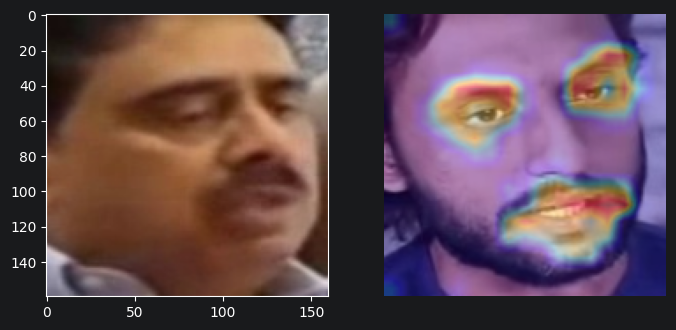

In [10]:
dataset_path = "/home/wiktor/Doktorat/repositories/mavceleb_baseline/dataset/mavceleb_v1_train/faces"
language = "English"

identity_ids = os.listdir(dataset_path)
while True:
    ids_pair = np.random.choice(identity_ids, 2)
    id_1 = ids_pair[0]
    id_2 = ids_pair[1]
    if id_1 != id_2:
        break

folder_1 = np.random.choice(os.listdir(os.path.join(dataset_path, id_1, language)), 1)[0]
file_1 = np.random.choice(os.listdir(os.path.join(dataset_path, id_1, language, folder_1)), 1)[0]
face_1_path = os.path.join(dataset_path, id_1, language, folder_1, file_1)

folder_2 = np.random.choice(os.listdir(os.path.join(dataset_path, id_2, language)), 1)[0]
file_2 = np.random.choice(os.listdir(os.path.join(dataset_path, id_2, language, folder_2)), 1)[0]
face_2_path = os.path.join(dataset_path, id_2, language, folder_2, file_2)

print(face_1_path)
print(face_2_path)
img1_pil = Image.open(face_1_path).convert("RGB")
img2_pil = Image.open(face_2_path).convert("RGB")

img1 = mtcnn(img1_pil)  # shape: [3,160,160]
img2 = mtcnn(img2_pil)
img1 = img1.unsqueeze(0).to(device)
img2 = img2.unsqueeze(0).to(device)
with torch.no_grad():
    ref_embedding = model(img2)  # [1, 512]
targets = [SimilarityTarget(ref_embedding)]

grayscale_cam = cam(
    input_tensor=img1,
    targets=targets
)
img_vis = img1[0].detach().cpu().permute(1, 2, 0).numpy()
img_vis = (img_vis - img_vis.min()) / (img_vis.max() - img_vis.min())
visualization = show_cam_on_image(img_vis, grayscale_cam[0], use_rgb=True, image_weight=0.7)
plt.figure(figsize=[8, 8])
plt.subplot(1, 2, 1)
plt.imshow((img2.cpu().squeeze().permute(1, 2, 0).numpy() + 1) / 2)

plt.subplot(1, 2, 2)
plt.imshow(visualization)
plt.axis("off")
plt.show()

(1, 160, 160)


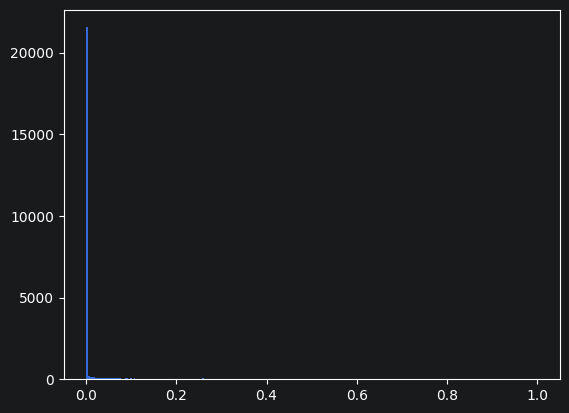

In [19]:
print(grayscale_cam.shape)
plt.hist(grayscale_cam.flatten(), bins=256)
plt.show()

In [230]:
np.sum(grayscale_cam)

9032.124